# 셀 전압 패턴 분석
- 이 파일은 셀 전압의 패턴을 분석합니다.

<br/>

## 과정
1. 특징 추출 및 추세 비교
2. 이상 패턴 탐지
3. 시각화

In [2]:
# 라이브러리
print("===== 라이브러리 import 실행 ======")
try:
    import pandas as pd
    import os
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt
    print("라이브러리 import 완료")
except Exception as e:
    print(f"오류 발생: {e}")
print("")


===== 라이브러리 import 실행 ======
라이브러리 import 완료



## 1. 특징 추출  및 추세 비교

특징 추출 및 추세 비교 작업 시작
dchg 파일 접근 중
====== cell_1043_dchg.csv ======


C:\Users\SSAFY\AppData\Local\Temp\ipykernel_1104\2016031429.py:25: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  cols = df.columns[df.columns.to_series().str.contains(pattern, regex=True)].tolist()


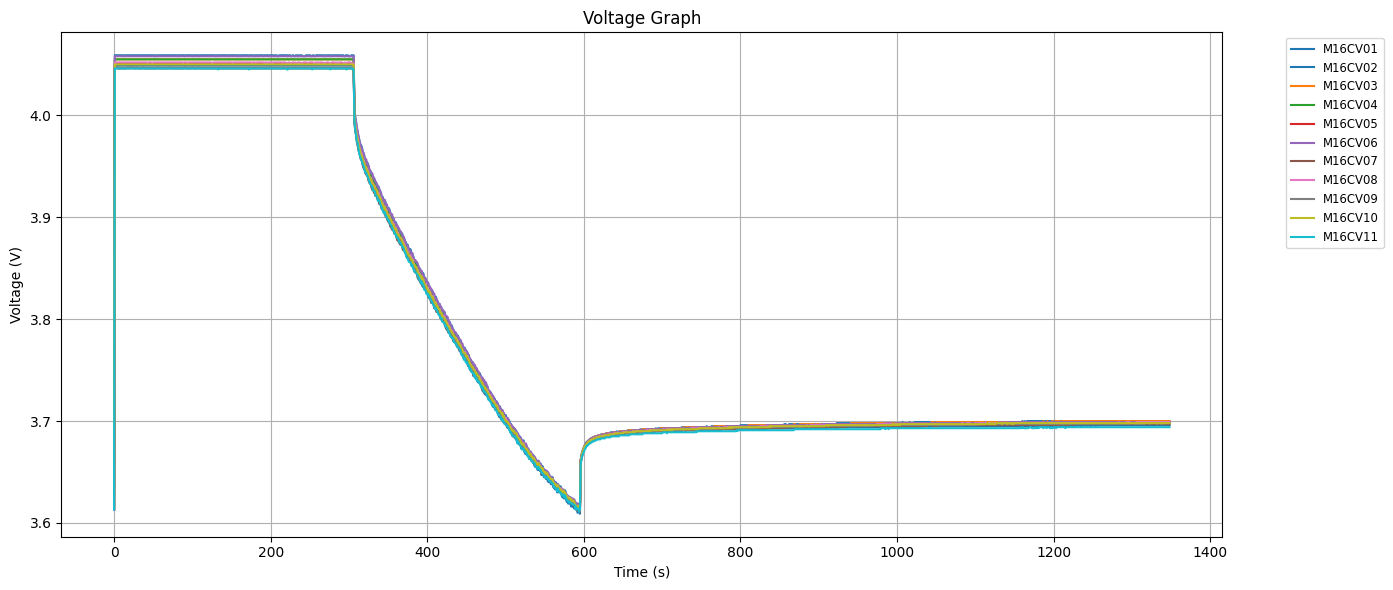


작업 종료


In [7]:
print("특징 추출 및 추세 비교 작업 시작")
# 데이터 불러오기
try:
    # 입력 폴더 경로 설정
    input_dir = '../data/processed/raw_cell'

    # 충/방전 데이터 선택
    # 충전: chg, 방전: dchg
    mode = 'dchg'

    # 모든 CSV 파일 순회
    print(f"{mode} 파일 접근 중")
    for filename in os.listdir(input_dir):
        if filename.endswith(f'1043_{mode}.csv'):
            filepath = os.path.join(input_dir, filename)

            # 해당 파일의 데이터프레임 생성
            df = pd.read_csv(filepath)

            # 전압값 열 선택
            # 전체 열의 패턴
            # pattern = r'^M[0-9]{2}CV[0-9]{2}$'
            # M01의 CV01 부터 CV11 까지 선택
            pattern = r'^M16CV(0[1-9]|10|11)$'
            cols = df.columns[df.columns.to_series().str.contains(pattern, regex=True)].tolist()
            df_vol = df[cols].copy()
            
            # 분석 작업할 코드 영역
            print(f"====== {filename} ======")
            # features = df_vol.agg(['mean', 'std', 'min', 'max', 'median'])
            # print(features.head())

            # 색상 컬러맵 설정 (여러 셀을 구별할 수 있도록 충분한 색상 생성)
            cmap = plt.get_cmap('tab10')  # Deprecated warning 제거
            colors = [cmap(i / len(cols)) for i in range(len(cols))]  # 각 셀에 맞는 색상

            # 플로팅
            plt.figure(figsize=(14, 6))

            for i, col in enumerate(cols):
                plt.plot(df.index, df_vol[col], label=col, color=colors[i])  # 각 셀 전압을 다른 색상으로 표시

            plt.title("Voltage Graph")
            plt.xlabel("Time (s)")
            plt.ylabel("Voltage (V)")
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')  # 오른쪽 바깥에 범례
            plt.grid(True)
            plt.tight_layout()  # 레이아웃 최적화
            plt.show()
            print("=========================")
            print("")

            # 50개 파일 중 1개만 보기 위한 break
            break
    print("작업 종료")

except Exception as e:
    print(f"오류 발생: {e}")